# Backend OCR Pipeline

Run all cells from top to bottom. The notebook is ordered as:

1. Setup and configuration
2. Dataset loading and optional demo-data generation
3. Vocabulary, ViT OCR model, CTC loss, and decoders
4. Training loop
5. Evaluation
6. OCR inference helper and optional FastAPI app definition

The default settings are intentionally small so `Run All` finishes on a laptop. Increase `MAX_SAMPLES`, `EPOCHS`, and model size in the config cell for real training.


In [11]:
from __future__ import annotations

import csv
import io
import json
import random
import string
import sys
from dataclasses import dataclass
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw, ImageEnhance, ImageFilter, ImageFont
import tensorflow as tf

try:
    sys.stdout.reconfigure(encoding="utf-8")
    sys.stderr.reconfigure(encoding="utf-8")
except Exception:
    pass

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent.resolve()

print("Repo root:", REPO_ROOT)
print("TensorFlow:", tf.__version__)


Repo root: C:\Users\iworo\Documents\GGSN\prject\GGSN_Project
TensorFlow: 2.21.0


In [12]:
# Pipeline configuration. These defaults are a fast smoke pipeline.
# For a stronger run, set FAST_DEV_RUN = False and increase EPOCHS.
FAST_DEV_RUN = True

MANIFEST_PATH = REPO_ROOT / "data" / "manifest.csv"
ROOT_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "artifacts_notebook"

IMAGE_SIZE = 128 if FAST_DEV_RUN else 256
PATCH_SIZE = 8 if FAST_DEV_RUN else 16
EMBEDDING_DIM = 64 if FAST_DEV_RUN else 256
NUM_TRANSFORMER_BLOCKS = 1 if FAST_DEV_RUN else 4
BATCH_SIZE = 8
EPOCHS = 2 if FAST_DEV_RUN else 20
LEARNING_RATE = 1e-3 if FAST_DEV_RUN else 1e-4
VAL_SPLIT = 0.1
SEED = 42
MAX_SAMPLES = 64 if FAST_DEV_RUN else None
AUGMENT = not FAST_DEV_RUN
CLIPNORM = 1.0
BLANK_BIAS = 0.0

SAMPLE_IMAGE_PATH = REPO_ROOT / "test_upload.png"
if not SAMPLE_IMAGE_PATH.exists():
    SAMPLE_IMAGE_PATH = None

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output dir:", OUTPUT_DIR)


Output dir: C:\Users\iworo\Documents\GGSN\prject\GGSN_Project\artifacts_notebook


In [13]:
@dataclass(frozen=True)
class OCRSample:
    image_path: str
    text: str


@dataclass(frozen=True)
class OCRDatasetConfig:
    image_size: tuple[int, int] = (256, 256)
    batch_size: int = 8
    shuffle_buffer_size: int = 256
    cache: bool = False
    augment: bool = False
    augment_brightness_delta: float = 0.08
    augment_contrast_lower: float = 0.9
    augment_contrast_upper: float = 1.1
    augment_noise_stddev: float = 0.02


def read_manifest(csv_path, root_dir=None, image_column="image_path", text_column="text", encoding="utf-8-sig"):
    csv_path = Path(csv_path)
    root_dir = Path(root_dir) if root_dir is not None else csv_path.parent
    samples = []
    with csv_path.open("r", newline="", encoding=encoding) as file_handle:
        reader = csv.DictReader(file_handle)
        for row in reader:
            image_path = Path(row[image_column])
            if not image_path.is_absolute():
                image_path = root_dir / image_path
            samples.append(OCRSample(image_path=str(image_path), text=row[text_column]))
    return samples


def load_image(image_path, image_size=(256, 256)):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image


def encode_text(text, vocabulary):
    encoded = tf.py_function(
        func=lambda value: tf.convert_to_tensor(
            vocabulary.encode(value.numpy().decode("utf-8")), dtype=tf.int32
        ),
        inp=[text],
        Tout=tf.int32,
    )
    encoded.set_shape([None])
    return encoded


def augment_image(image, config: OCRDatasetConfig):
    image = tf.image.random_brightness(image, max_delta=config.augment_brightness_delta)
    image = tf.image.random_contrast(
        image,
        lower=config.augment_contrast_lower,
        upper=config.augment_contrast_upper,
    )
    noise = tf.random.normal(
        shape=tf.shape(image),
        mean=0.0,
        stddev=config.augment_noise_stddev,
        dtype=tf.float32,
    )
    return tf.clip_by_value(image + noise, 0.0, 1.0)


def build_dataset(samples, vocabulary, config: OCRDatasetConfig, training=True):
    image_paths = [sample.image_path for sample in samples]
    texts = [sample.text for sample in samples]
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, texts))

    if training:
        dataset = dataset.shuffle(
            min(len(samples), config.shuffle_buffer_size), reshuffle_each_iteration=True
        )

    def _load_example(image_path, text):
        image = load_image(image_path, config.image_size)
        if training and config.augment:
            image = augment_image(image, config)
        label = encode_text(text, vocabulary)
        return image, label

    dataset = dataset.map(_load_example, num_parallel_calls=tf.data.AUTOTUNE)
    if config.cache:
        dataset = dataset.cache()

    dataset = dataset.padded_batch(
        config.batch_size,
        padded_shapes=([config.image_size[0], config.image_size[1], 3], [None]),
        padding_values=(tf.constant(0.0, tf.float32), tf.constant(0, tf.int32)),
        drop_remainder=False,
    )
    return dataset.prefetch(tf.data.AUTOTUNE)


In [14]:
def generate_demo_data(manifest_path: Path, num_base_samples=80, variants_per_sample=2, seed=42):
    images_dir = manifest_path.parent / "images"
    images_dir.mkdir(parents=True, exist_ok=True)
    rng = random.Random(seed)
    base_words = [
        "alpha", "beta", "gamma", "delta", "test", "sample", "OCR", "Document",
        "Invoice", "Total", "Name", "Address", "Date", "Reference", "Amount",
        "Value", "OpenAI", "Hello", "World", "Data",
    ]

    def random_text():
        words = [rng.choice(base_words) for _ in range(rng.randint(2, 5))]
        if rng.random() < 0.3:
            words.append(str(rng.randint(1, 9999)))
        return " ".join(words)

    def make_image(path: Path, text: str, size=(256, 256)):
        image = Image.new("RGB", size, color=(255, 255, 255))
        draw = ImageDraw.Draw(image)
        try:
            font = ImageFont.truetype("arial.ttf", 24)
        except Exception:
            font = ImageFont.load_default()
        bbox = draw.textbbox((0, 0), text, font=font)
        x = (size[0] - (bbox[2] - bbox[0])) // 2
        y = (size[1] - (bbox[3] - bbox[1])) // 2
        draw.text((x, y), text, fill=(0, 0, 0), font=font)
        image.save(path)

    def augment_pil(image: Image.Image):
        augmented = image.rotate(
            rng.uniform(-4.0, 4.0),
            resample=Image.Resampling.BICUBIC,
            fillcolor=(255, 255, 255),
        )
        augmented = ImageEnhance.Brightness(augmented).enhance(rng.uniform(0.85, 1.15))
        augmented = ImageEnhance.Contrast(augmented).enhance(rng.uniform(0.85, 1.2))
        if rng.random() < 0.25:
            augmented = augmented.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.2, 0.8)))
        return augmented

    rows = []
    for index in range(1, num_base_samples + 1):
        text = random_text()
        rel_path = f"images/img_{index:04d}.png"
        image_path = manifest_path.parent / rel_path
        make_image(image_path, text)
        rows.append((rel_path, text))
        base_image = Image.open(image_path).convert("RGB")
        for variant_index in range(1, variants_per_sample + 1):
            variant_rel = f"images/img_{index:04d}_aug_{variant_index:02d}.png"
            augment_pil(base_image).save(manifest_path.parent / variant_rel)
            rows.append((variant_rel, text))
        base_image.close()

    with manifest_path.open("w", encoding="utf-8-sig", newline="") as handle:
        writer = csv.writer(handle)
        writer.writerow(["image_path", "text"])
        writer.writerows(rows)
    print(f"Generated {len(rows)} demo rows at {manifest_path}")


if not MANIFEST_PATH.exists():
    print("Manifest not found. Generating demo data.")
    generate_demo_data(MANIFEST_PATH)
else:
    print("Using manifest:", MANIFEST_PATH)


Using manifest: C:\Users\iworo\Documents\GGSN\prject\GGSN_Project\data\manifest.csv


In [15]:
class TransformBlock(tf.keras.layers.Layer):
    def __init__(self, num_heads=8, embedding_dim=256, dropout_rate=0.1):
        super().__init__()
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embedding_dim // num_heads,
            dropout=dropout_rate,
        )
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(embedding_dim * 4, activation="gelu"),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(embedding_dim),
        ])

    def call(self, x, training=False):
        attention_output = self.attention(self.norm1(x), self.norm1(x), training=training)
        x = x + attention_output
        mlp_output = self.mlp(self.norm2(x), training=training)
        return x + mlp_output


class ViTEncoder(tf.keras.Model):
    def __init__(self, image_size=256, patch_size=16, embedding_dim=256, num_transformer_blocks=4):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.embedding_dim = embedding_dim
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_embedding = tf.keras.layers.Conv2D(
            filters=embedding_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid",
        )
        self.cls_token = None
        self.position_embedding = None
        self.transformer_blocks = [
            TransformBlock(embedding_dim=embedding_dim) for _ in range(num_transformer_blocks)
        ]
        self.final_norm = tf.keras.layers.LayerNormalization()

    def build(self, input_shape):
        height = int(input_shape[1]) if input_shape[1] is not None else self.image_size
        width = int(input_shape[2]) if input_shape[2] is not None else self.image_size
        patches_h = max(1, height // self.patch_size)
        patches_w = max(1, width // self.patch_size)
        self.num_patches = patches_h * patches_w
        if self.cls_token is None:
            self.cls_token = self.add_weight(
                name="cls_token",
                shape=(1, 1, self.embedding_dim),
                initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
                trainable=True,
            )
        if self.position_embedding is None:
            self.position_embedding = self.add_weight(
                name="position_embedding",
                shape=(1, self.num_patches + 1, self.embedding_dim),
                initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
                trainable=True,
            )
        super().build(input_shape)

    def _prepare_tokens(self, image):
        x = self.patch_embedding(image)
        batch_size = tf.shape(x)[0]
        x = tf.reshape(x, [batch_size, -1, self.embedding_dim])
        cls_tokens = tf.repeat(self.cls_token, repeats=batch_size, axis=0)
        return tf.concat([cls_tokens, x], axis=1) + self.position_embedding

    def call(self, image, training=False, return_sequence=False):
        if self.cls_token is None or self.position_embedding is None:
            self.build(image.shape)
        x = self._prepare_tokens(image)
        for block in self.transformer_blocks:
            x = block(x, training=training)
        x = self.final_norm(x)
        if return_sequence:
            return x
        return x[:, 0]


class ViTOCR(tf.keras.Model):
    def __init__(self, vocab_size, image_size=256, patch_size=16, embedding_dim=256, num_transformer_blocks=4, blank_bias=0.0):
        super().__init__()
        self.encoder = ViTEncoder(
            image_size=image_size,
            patch_size=patch_size,
            embedding_dim=embedding_dim,
            num_transformer_blocks=num_transformer_blocks,
        )
        self.token_projection = tf.keras.layers.Dense(vocab_size)
        self._vocab_size = vocab_size
        self._blank_bias = blank_bias

    def build(self, input_shape):
        self.encoder.build(input_shape)
        batch = 1
        height = input_shape[1] if input_shape[1] is not None else self.encoder.image_size
        width = input_shape[2] if input_shape[2] is not None else self.encoder.image_size
        sequence = self.encoder(tf.zeros([batch, height, width, 3]), training=False, return_sequence=True)
        _ = self.token_projection(sequence[:, 1:, :])
        if self._blank_bias != 0.0 and self.token_projection.bias is not None:
            bias = tf.zeros_like(self.token_projection.bias)
            blank_index = tf.cast(self._vocab_size - 1, tf.int32)
            bias = tf.tensor_scatter_nd_add(
                bias, [[blank_index]], [tf.cast(self._blank_bias, bias.dtype)]
            )
            self.token_projection.bias.assign(bias)
        super().build(input_shape)

    def call(self, image, training=False):
        sequence = self.encoder(image, training=training, return_sequence=True)
        patch_tokens = sequence[:, 1:, :]
        return self.token_projection(patch_tokens)


In [16]:
class OCRVocabulary:
    def __init__(self, characters=None):
        if characters is None:
            characters = string.ascii_lowercase + string.ascii_uppercase + string.digits + " " + string.punctuation
        self.characters = characters
        self.char_to_id = {char: index + 1 for index, char in enumerate(characters)}
        self.id_to_char = {index + 1: char for index, char in enumerate(characters)}
        self.blank_id = len(characters) + 1

    @property
    def size(self):
        return len(self.characters) + 2

    def encode(self, text):
        missing_chars = sorted({char for char in text if char not in self.char_to_id})
        if missing_chars:
            raise ValueError(f"Unsupported OCR characters: {missing_chars}")
        return [self.char_to_id[char] for char in text]

    def decode(self, token_ids):
        decoded_chars = []
        for token_id in token_ids:
            token_id = int(token_id)
            if token_id == 0 or token_id == self.blank_id:
                continue
            char = self.id_to_char.get(token_id)
            if char is not None:
                decoded_chars.append(char)
        return "".join(decoded_chars)


def build_ctc_input_lengths(batch_size, time_steps):
    return tf.fill([batch_size], tf.cast(time_steps, tf.int32))


def build_ctc_label_lengths_from_blank(labels, blank_id=None):
    labels = tf.convert_to_tensor(labels)
    mask = tf.not_equal(labels, tf.cast(0, labels.dtype))
    if blank_id is not None:
        mask = tf.logical_and(mask, tf.not_equal(labels, tf.cast(blank_id, labels.dtype)))
    return tf.reduce_sum(tf.cast(mask, tf.int32), axis=1)


def ctc_loss(labels, logits, blank_id=None):
    batch_size = tf.shape(logits)[0]
    time_steps = tf.shape(logits)[1]
    input_lengths = build_ctc_input_lengths(batch_size, time_steps)
    label_lengths = build_ctc_label_lengths_from_blank(labels, blank_id=blank_id)
    if blank_id is None:
        blank_id = tf.shape(logits)[-1] - 1
    loss = tf.nn.ctc_loss(
        labels=tf.cast(labels, tf.int32),
        logits=logits,
        label_length=label_lengths,
        logit_length=input_lengths,
        logits_time_major=False,
        blank_index=tf.cast(blank_id, tf.int32),
    )
    return tf.expand_dims(loss, axis=-1)


def greedy_ctc_decode(logits, vocabulary):
    logits = tf.convert_to_tensor(logits)
    token_ids = tf.argmax(logits, axis=-1, output_type=tf.int32).numpy()
    decoded_texts = []
    for row in token_ids:
        collapsed = []
        previous_token = None
        for token_id in row:
            token_id = int(token_id)
            if token_id == vocabulary.blank_id:
                previous_token = token_id
                continue
            if previous_token == token_id:
                continue
            collapsed.append(token_id)
            previous_token = token_id
        decoded_texts.append(vocabulary.decode(collapsed))
    return decoded_texts


def beam_search_ctc_decode(logits, vocabulary, beam_width=8, top_paths=1):
    logits = tf.convert_to_tensor(logits)
    inputs = tf.transpose(logits, perm=[1, 0, 2])
    batch_size = tf.shape(logits)[0]
    time_steps = tf.shape(logits)[1]
    sequence_length = tf.fill([batch_size], tf.cast(time_steps, tf.int32))
    decoded, _ = tf.nn.ctc_beam_search_decoder(
        inputs, sequence_length, beam_width=beam_width, top_paths=top_paths
    )
    dense = tf.sparse.to_dense(decoded[0], default_value=0).numpy()
    return [vocabulary.decode(row) for row in dense]


In [17]:
def edit_distance(source: str, target: str) -> int:
    if source == target:
        return 0
    if not source:
        return len(target)
    if not target:
        return len(source)
    previous = list(range(len(target) + 1))
    for i, source_char in enumerate(source, start=1):
        current = [i]
        for j, target_char in enumerate(target, start=1):
            current.append(min(
                current[j - 1] + 1,
                previous[j] + 1,
                previous[j - 1] + (0 if source_char == target_char else 1),
            ))
        previous = current
    return previous[-1]


def split_samples(samples, val_split=0.1, seed=42):
    shuffled = samples[:]
    random.Random(seed).shuffle(shuffled)
    val_count = int(len(shuffled) * val_split)
    if val_split > 0 and val_count == 0 and len(shuffled) > 1:
        val_count = 1
    if val_count >= len(shuffled):
        val_count = max(0, len(shuffled) - 1)
    return shuffled[val_count:], shuffled[:val_count]


def labels_to_texts(labels, vocabulary):
    texts = []
    for row in labels.numpy():
        token_ids = [int(token_id) for token_id in row if int(token_id) != 0 and int(token_id) != vocabulary.blank_id]
        texts.append(vocabulary.decode(token_ids))
    return texts


def sequence_metrics(labels, logits, vocabulary):
    predictions = greedy_ctc_decode(logits, vocabulary)
    targets = labels_to_texts(labels, vocabulary)
    if not targets:
        return 0.0, 0.0
    exact = 0
    char_acc_sum = 0.0
    for prediction, target in zip(predictions, targets):
        exact += int(prediction == target)
        distance = edit_distance(prediction, target)
        char_acc_sum += max(0.0, 1.0 - distance / max(1, len(target)))
    return char_acc_sum / len(targets), exact / len(targets)


def prediction_diagnostics(logits, vocabulary):
    predictions = greedy_ctc_decode(logits, vocabulary)
    token_ids = tf.argmax(logits, axis=-1, output_type=tf.int32)
    blank_rate = tf.reduce_mean(tf.cast(tf.equal(token_ids, vocabulary.blank_id), tf.float32))
    probs = tf.nn.softmax(logits, axis=-1)
    mean_max_prob = tf.reduce_mean(tf.reduce_max(probs, axis=-1))
    empty_rate = sum(1 for prediction in predictions if prediction == "") / max(1, len(predictions))
    return float(blank_rate.numpy()), empty_rate, float(mean_max_prob.numpy())


def train_step(model, images, labels, optimizer, blank_id):
    with tf.GradientTape() as tape:
        logits = model(images, training=True)
        loss_value = tf.reduce_mean(ctc_loss(labels, logits, blank_id=blank_id))
    gradients = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss_value, logits


def eval_step(model, images, labels, blank_id):
    logits = model(images, training=False)
    loss_value = tf.reduce_mean(ctc_loss(labels, logits, blank_id=blank_id))
    return loss_value, logits


In [18]:
def prepare_samples():
    samples = read_manifest(MANIFEST_PATH, root_dir=ROOT_DIR)
    if MAX_SAMPLES is not None:
        samples = samples[:MAX_SAMPLES]
    patches_per_side = max(1, IMAGE_SIZE // PATCH_SIZE)
    time_steps = patches_per_side * patches_per_side
    samples = [sample for sample in samples if len(sample.text) <= time_steps]
    if not samples:
        raise ValueError("No samples remain after length filtering.")
    all_text = "".join(sample.text for sample in samples)
    characters = "".join(sorted(set(all_text)))
    vocabulary = OCRVocabulary(characters=characters)
    train_samples, val_samples = split_samples(samples, val_split=VAL_SPLIT, seed=SEED)
    if not val_samples:
        val_samples = train_samples[:]
    print(f"Samples: total={len(samples)} train={len(train_samples)} val={len(val_samples)}")
    print(f"Time steps: {time_steps} | max label length: {max(len(sample.text) for sample in samples)}")
    print(f"Vocabulary size: {vocabulary.size} | characters={vocabulary.characters!r}")
    return samples, train_samples, val_samples, vocabulary


all_samples, train_samples, val_samples, vocabulary = prepare_samples()


Samples: total=64 train=58 val=6
Time steps: 256 | max label length: 44
Vocabulary size: 38 | characters=' 236789ACDHINORTVWacdefghilmnoprstuv'


In [19]:
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

data_config = OCRDatasetConfig(
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle_buffer_size=max(BATCH_SIZE * 8, 64),
    augment=AUGMENT,
)
train_ds = build_dataset(train_samples, vocabulary, data_config, training=True)
val_ds = build_dataset(val_samples, vocabulary, data_config, training=False)

model = ViTOCR(
    vocab_size=vocabulary.size,
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
    blank_bias=BLANK_BIAS,
)
model.build((None, IMAGE_SIZE, IMAGE_SIZE, 3))
_ = model(tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 3), dtype=tf.float32), training=False)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=CLIPNORM)
model.summary()


Model: "vi_tocr_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vi_t_encoder_1 (ViTEncoder)     │ ?                      │        78,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 256, 38)           │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,446 (318.15 KB)

 Trainable params: 81,446 (318.15 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
best_val_loss = float("inf")
best_weights_path = OUTPUT_DIR / "best.weights.h5"
final_weights_path = OUTPUT_DIR / "final.weights.h5"

for epoch in range(1, EPOCHS + 1):
    train_losses = []
    train_char_accs = []
    train_seq_accs = []
    train_blank_rates = []
    train_empty_rates = []

    for images, labels in train_ds:
        loss_value, logits = train_step(model, images, labels, optimizer, blank_id=vocabulary.blank_id)
        char_acc, seq_acc = sequence_metrics(labels, logits, vocabulary)
        blank_rate, empty_rate, _ = prediction_diagnostics(logits, vocabulary)
        train_losses.append(float(loss_value.numpy()))
        train_char_accs.append(char_acc)
        train_seq_accs.append(seq_acc)
        train_blank_rates.append(blank_rate)
        train_empty_rates.append(empty_rate)

    val_losses = []
    val_char_accs = []
    val_seq_accs = []
    val_blank_rates = []
    val_empty_rates = []

    for images, labels in val_ds:
        loss_value, logits = eval_step(model, images, labels, blank_id=vocabulary.blank_id)
        char_acc, seq_acc = sequence_metrics(labels, logits, vocabulary)
        blank_rate, empty_rate, _ = prediction_diagnostics(logits, vocabulary)
        val_losses.append(float(loss_value.numpy()))
        val_char_accs.append(char_acc)
        val_seq_accs.append(seq_acc)
        val_blank_rates.append(blank_rate)
        val_empty_rates.append(empty_rate)

    train_loss = sum(train_losses) / max(1, len(train_losses))
    val_loss = sum(val_losses) / max(1, len(val_losses))
    print(
        f"Epoch {epoch:03d}/{EPOCHS} "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"train_char_acc={np.mean(train_char_accs):.4f} val_char_acc={np.mean(val_char_accs):.4f} "
        f"train_seq_acc={np.mean(train_seq_accs):.4f} val_seq_acc={np.mean(val_seq_accs):.4f} "
        f"train_blank_rate={np.mean(train_blank_rates):.4f} val_blank_rate={np.mean(val_blank_rates):.4f} "
        f"train_empty_rate={np.mean(train_empty_rates):.4f} val_empty_rate={np.mean(val_empty_rates):.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_weights(best_weights_path)
        print("Saved best weights:", best_weights_path)

model.save_weights(final_weights_path)
config_path = OUTPUT_DIR / "model_config.json"
config_path.write_text(json.dumps({
    "image_size": IMAGE_SIZE,
    "patch_size": PATCH_SIZE,
    "embedding_dim": EMBEDDING_DIM,
    "num_transformer_blocks": NUM_TRANSFORMER_BLOCKS,
    "vocabulary": vocabulary.characters,
    "blank_bias": BLANK_BIAS,
}, indent=2), encoding="utf-8")
print("Saved final weights:", final_weights_path)
print("Saved config:", config_path)


Epoch 001/2 train_loss=438.2503 val_loss=294.4285 train_char_acc=0.0293 val_char_acc=0.0457 train_seq_acc=0.0000 val_seq_acc=0.0000 train_blank_rate=0.0001 val_blank_rate=0.0000 train_empty_rate=0.0000 val_empty_rate=0.0000
Saved best weights: C:\Users\iworo\Documents\GGSN\prject\GGSN_Project\artifacts_notebook\best.weights.h5
Epoch 002/2 train_loss=345.2595 val_loss=213.9354 train_char_acc=0.0197 val_char_acc=0.0739 train_seq_acc=0.0000 val_seq_acc=0.0000 train_blank_rate=0.0000 val_blank_rate=0.0000 train_empty_rate=0.0000 val_empty_rate=0.0000
Saved best weights: C:\Users\iworo\Documents\GGSN\prject\GGSN_Project\artifacts_notebook\best.weights.h5
Saved final weights: C:\Users\iworo\Documents\GGSN\prject\GGSN_Project\artifacts_notebook\final.weights.h5
Saved config: C:\Users\iworo\Documents\GGSN\prject\GGSN_Project\artifacts_notebook\model_config.json


In [21]:
def evaluate_dataset(model, dataset, vocabulary, examples=8):
    total = 0
    exact = 0
    char_edits = 0
    char_total = 0
    empty = 0
    blank_argmax = 0
    argmax_total = 0
    sample_examples = []

    for images, labels in dataset:
        logits = model(images, training=False)
        predictions = greedy_ctc_decode(logits, vocabulary)
        targets = labels_to_texts(labels, vocabulary)
        argmax_ids = tf.argmax(logits, axis=-1, output_type=tf.int32).numpy()
        blank_argmax += int(np.sum(argmax_ids == vocabulary.blank_id))
        argmax_total += int(argmax_ids.size)
        for prediction, target in zip(predictions, targets):
            total += 1
            exact += int(prediction == target)
            empty += int(prediction == "")
            char_edits += edit_distance(prediction, target)
            char_total += len(target)
            if len(sample_examples) < examples:
                sample_examples.append((target, prediction))

    metrics = {
        "samples": total,
        "exact_match": exact / max(1, total),
        "char_error_rate": char_edits / max(1, char_total),
        "char_accuracy": 1.0 - (char_edits / max(1, char_total)),
        "empty_prediction_rate": empty / max(1, total),
        "blank_argmax_rate": blank_argmax / max(1, argmax_total),
        "examples": sample_examples,
    }
    return metrics


val_metrics = evaluate_dataset(model, val_ds, vocabulary)
print(json.dumps({k: v for k, v in val_metrics.items() if k != "examples"}, indent=2))
print("Examples:")
for target, prediction in val_metrics["examples"]:
    print(f"target={target!r} prediction={prediction!r}")


{
  "samples": 6,
  "exact_match": 0.0,
  "char_error_rate": 0.9324324324324325,
  "char_accuracy": 0.06756756756756754,
  "empty_prediction_rate": 0.0,
  "blank_argmax_rate": 0.0
}
Examples:
target='Data gamma' prediction='t'
target='Data Data' prediction='t'
target='delta Hello' prediction='t'
target='Data gamma' prediction='t'
target='Date OCR delta OCR Value' prediction='t'
target='Name World' prediction='t'


Image: C:\Users\iworo\Documents\GGSN\prject\GGSN_Project\test_upload.png
Prediction: 't'
Logits shape: (1, 256, 38)


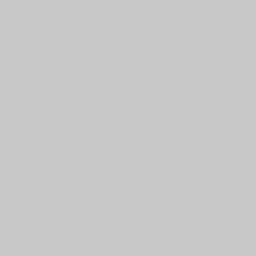

In [22]:
def preprocess_pil(image: Image.Image, image_size=(IMAGE_SIZE, IMAGE_SIZE)) -> np.ndarray:
    image = image.convert("RGB").resize(image_size)
    return np.asarray(image).astype("float32") / 255.0


def predict_image(image_path: str | Path, model=model, vocabulary=vocabulary):
    image_path = Path(image_path)
    image = Image.open(image_path)
    array = preprocess_pil(image)
    logits = model(np.expand_dims(array, axis=0), training=False)
    prediction = greedy_ctc_decode(logits, vocabulary)[0]
    return prediction, tuple(logits.shape)


if SAMPLE_IMAGE_PATH is None:
    SAMPLE_IMAGE_PATH = Path(val_samples[0].image_path)

prediction, logits_shape = predict_image(SAMPLE_IMAGE_PATH)
print("Image:", SAMPLE_IMAGE_PATH)
print("Prediction:", repr(prediction))
print("Logits shape:", logits_shape)
Image.open(SAMPLE_IMAGE_PATH)


In [23]:
# Optional FastAPI backend definition. This cell defines the app but does not run a server,
# so Run All will not block. Start it manually with uvicorn in a normal Python file/script if needed.
try:
    from fastapi import FastAPI, File, HTTPException, UploadFile
    from fastapi.middleware.cors import CORSMiddleware

    app = FastAPI()
    app.add_middleware(
        CORSMiddleware,
        allow_origins=["http://localhost:5173", "http://localhost:5174"],
        allow_credentials=True,
        allow_methods=["*"],
        allow_headers=["*"],
    )

    @app.post("/upload")
    async def upload_image(file: UploadFile = File(...)):
        contents = await file.read()
        try:
            image = Image.open(io.BytesIO(contents))
        except Exception as exc:
            raise HTTPException(status_code=400, detail=f"Invalid image file: {exc}")
        array = preprocess_pil(image)
        logits = model(np.expand_dims(array, axis=0), training=False)
        prediction = greedy_ctc_decode(logits, vocabulary)[0]
        return {"filename": file.filename, "prediction": prediction, "logits_shape": tuple(logits.shape)}

    print("FastAPI app is defined as `app`.")
except Exception as exc:
    app = None
    print("FastAPI app was not created:", exc)


FastAPI app is defined as `app`.
